<a href="https://colab.research.google.com/github/Qarym/Covid-19-Data-Analysis/blob/main/Data_Cleaning_%26Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [6]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')

In [7]:
df.shape

(8807, 12)

In [9]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [12]:
def data_clean(df):
  df.fillna(0, inplace=True)
  print(df.isnull().sum())

In [13]:
data_clean(df)

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [14]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

## Univariate Analysis

First, let's explore the distribution of individual features in your dataset.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Descriptive statistics for numerical columns
print("\nDescriptive Statistics for Numerical Columns:")
display(df.describe())


Descriptive Statistics for Numerical Columns:


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### Analysis of `type` (Movie vs. TV Show)

Let's see the distribution of content types.


Value Counts for 'type' column:


,count
type,
Movie,6131
TV Show,2676


/tmp/ipykernel_2557/3934438936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


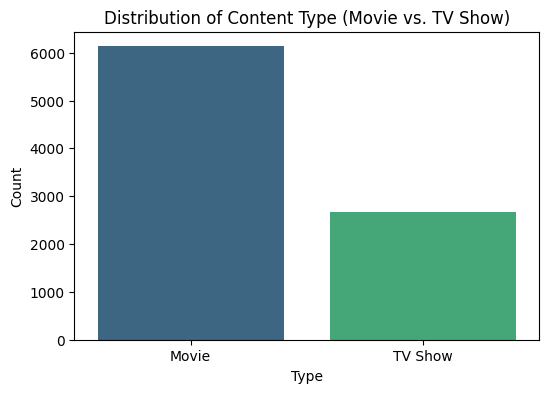

In [16]:
print("\nValue Counts for 'type' column:")
display(df['type'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', palette='viridis')
plt.title('Distribution of Content Type (Movie vs. TV Show)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

### Analysis of `release_year`

Let's look at the distribution of content release years.


Value Counts for 'release_year' column (Top 10):


,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


/tmp/ipykernel_2557/912870251.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['release_year'], bins=30, kde=True, palette='magma')


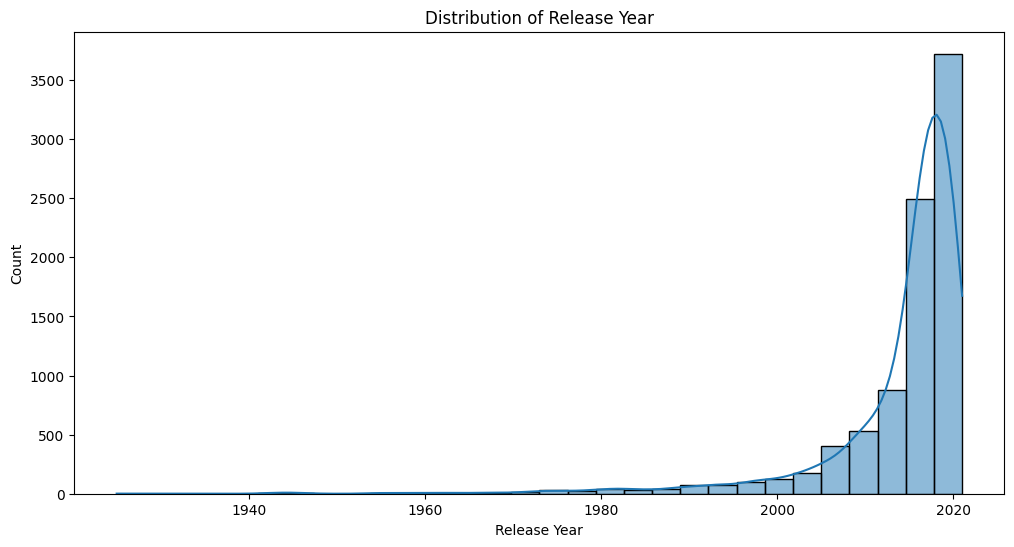

In [17]:
print("\nValue Counts for 'release_year' column (Top 10):")
display(df['release_year'].value_counts().head(10))

plt.figure(figsize=(12, 6))
sns.histplot(df['release_year'], bins=30, kde=True, palette='magma')
plt.title('Distribution of Release Year')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

### Analysis of `rating`

Let's examine the distribution of content ratings.


Value Counts for 'rating' column:


,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


/tmp/ipykernel_2557/2697224017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='plasma')


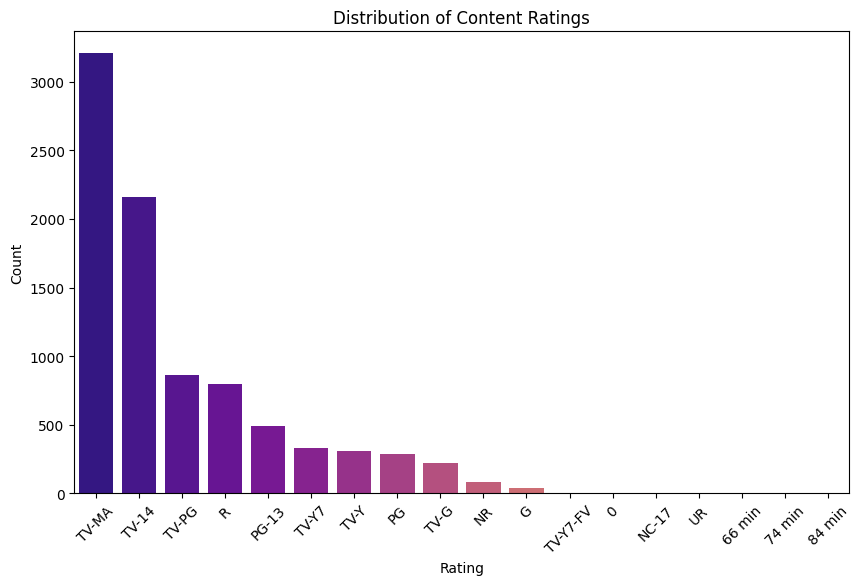

In [18]:
print("\nValue Counts for 'rating' column:")
display(df['rating'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, palette='plasma')
plt.title('Distribution of Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

### Analysis of `country` (Top 10)

Given the large number of unique countries, let's look at the top 10 contributing countries.


Value Counts for 'country' column (Top 10):


,count
country,
United States,2818
India,972
0,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


/tmp/ipykernel_2557/571373018.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='cubehelix')


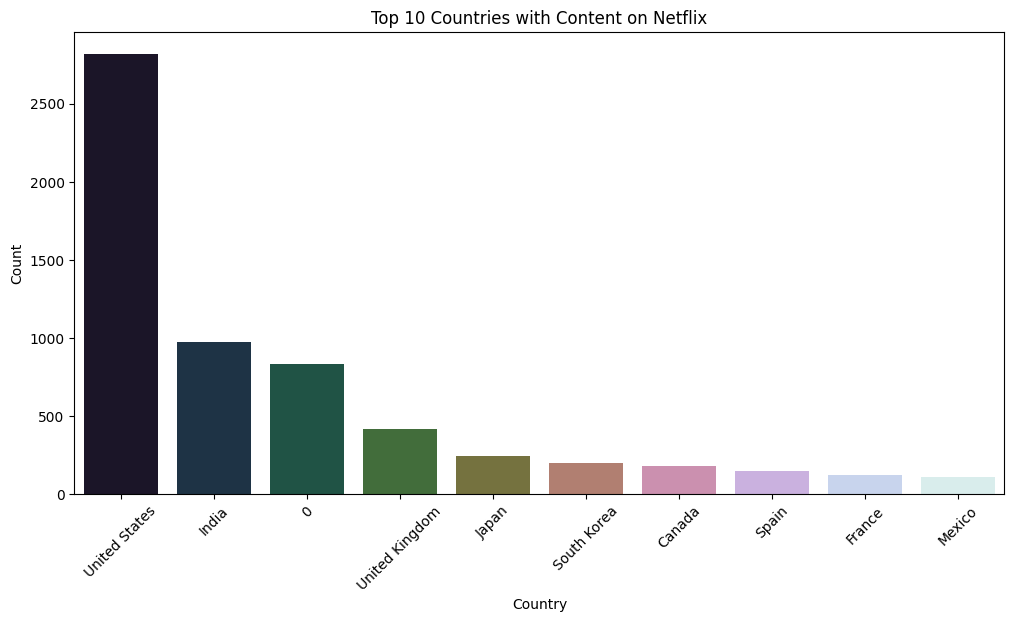

In [19]:
print("\nValue Counts for 'country' column (Top 10):")
# 'country' column has 0s from fillna, so filter them out if we want to see actual countries.
# For univariate, we can still show the count of '0' if it's significant.
top_10_countries = df['country'].value_counts().head(10)
display(top_10_countries)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_countries.index, y=top_10_countries.values, palette='cubehelix')
plt.title('Top 10 Countries with Content on Netflix')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

---

## Bivariate Analysis

Now, let's explore relationships between pairs of variables.

### Relationship between `type` and `release_year`

Let's see how the release year distribution differs for Movies and TV Shows.

/tmp/ipykernel_2557/1228400015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='release_year', palette='viridis')


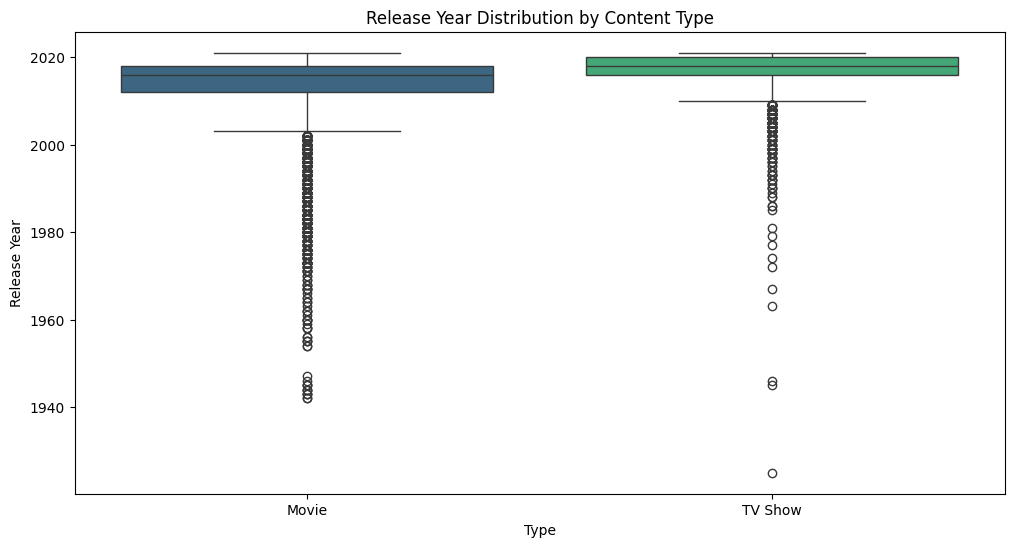

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='type', y='release_year', palette='viridis')
plt.title('Release Year Distribution by Content Type')
plt.xlabel('Type')
plt.ylabel('Release Year')
plt.show()

### Relationship between `type` and `rating`

Let's explore if certain ratings are more prevalent for Movies versus TV Shows.

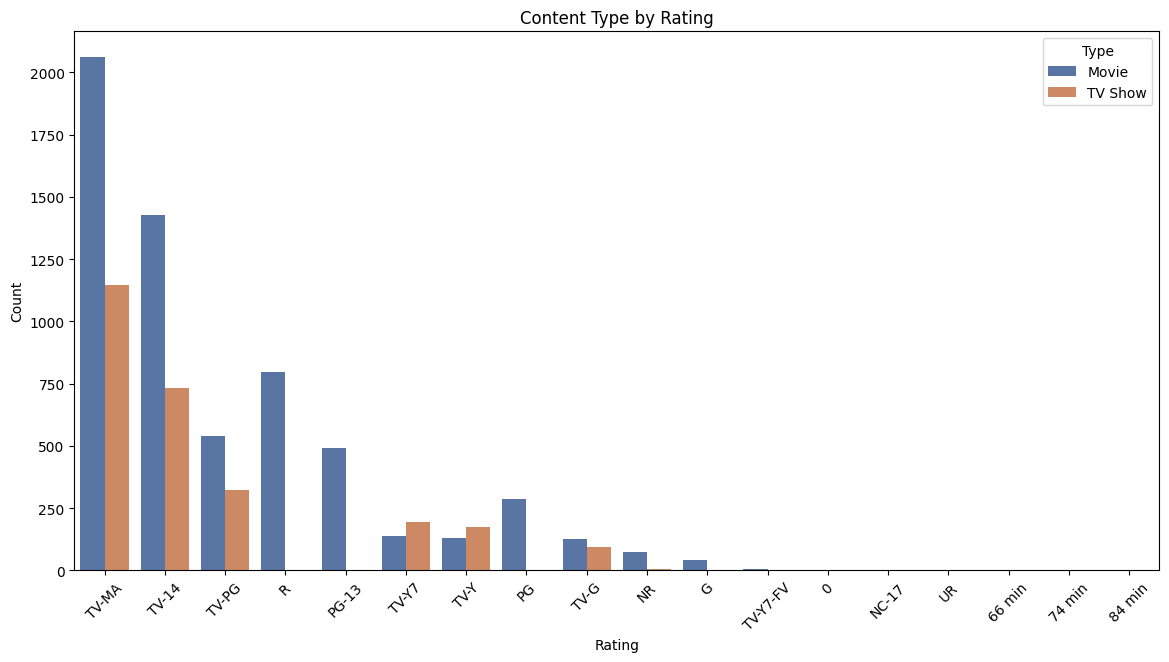

In [21]:
plt.figure(figsize=(14, 7))
sns.countplot(data=df, x='rating', hue='type', order=df['rating'].value_counts().index, palette='deep')
plt.title('Content Type by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()

## Feature Engineering and Importance

Identifying important features involves understanding which variables have the most predictive power or the strongest relationship with other variables in your dataset. This can help in feature selection, reducing dimensionality, and building more effective models.

Here are some common approaches:

1.  **Correlation Analysis:** For numerical features, this helps identify linear relationships between variables.
2.  **Statistical Tests:** For categorical features, tests like Chi-squared can reveal associations between them.
3.  **Feature Importance from Models:** Tree-based models (e.g., Random Forest, Gradient Boosting) can provide built-in feature importance scores.
4.  **Domain Knowledge:** Understanding the context of your data is always key to identifying relevant features.

Let's start by preparing the `duration` column and then performing some statistical analyses.

### Cleaning `duration` column

The `duration` column contains both 'min' for movies and 'Season(s)' for TV shows. To make it useful for numerical analysis, we need to extract the numerical part and convert it to an integer. We'll also create a new column `duration_type` to distinguish between 'Movie' duration (in minutes) and 'TV Show' duration (in seasons).

In [22]:
import numpy as np

def clean_duration(df_copy):
    # Create a copy to avoid modifying the original DataFrame directly in place for this operation
    df_copy = df_copy.copy()

    # Extract numerical duration and store the unit type
    df_copy['duration_value'] = df_copy['duration'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) and x.split(' ')[0].isdigit() else np.nan)
    df_copy['duration_unit'] = df_copy['duration'].apply(lambda x: x.split(' ')[1] if isinstance(x, str) and len(x.split(' ')) > 1 else np.nan)

    # Fill NaN values in duration_value that might have been caused by '0' or other non-string entries
    # Since we filled NaNs with '0' earlier, some durations might be '0'. We'll treat these as 0 for value but still identify unit if possible.
    df_copy.loc[df_copy['duration'] == '0', 'duration_value'] = 0
    df_copy.loc[df_copy['duration'] == '0', 'duration_unit'] = 'unknown'

    # For cases where duration was '0' or malformed and didn't fit the 'X unit' pattern,
    # we can try to infer the duration unit from the 'type' column, or set it to 'unknown'
    df_copy.loc[(df_copy['duration_unit'].isna()) & (df_copy['type'] == 'Movie'), 'duration_unit'] = 'min'
    df_copy.loc[(df_copy['duration_unit'].isna()) & (df_copy['type'] == 'TV Show'), 'duration_unit'] = 'Season'
    df_copy.loc[df_copy['duration_unit'].isna(), 'duration_unit'] = 'unknown'

    print("Cleaned duration head:")
    display(df_copy[['duration', 'duration_value', 'duration_unit']].head())
    print("Value counts for duration_unit:")
    display(df_copy['duration_unit'].value_counts())

    return df_copy

df_cleaned = clean_duration(df)


Cleaned duration head:


,duration,duration_value,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons


Value counts for duration_unit:


,count
duration_unit,
min,6131
Season,1793
Seasons,883


### Correlation Analysis for Numerical Features

We can examine the correlation between numerical features like `release_year` and the newly cleaned `duration_value`.

Correlation matrix for numerical features:


,release_year,duration_value
release_year,1.000000,-0.249182
duration_value,-0.249182,1.000000


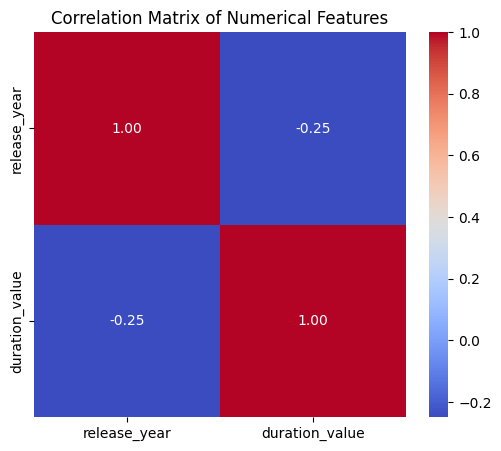

In [23]:
numerical_df = df_cleaned[['release_year', 'duration_value']].copy()

# Drop rows where 'duration_value' is NaN (e.g., where original duration was not a recognizable format)
numerical_df.dropna(inplace=True)

print("Correlation matrix for numerical features:")
display(numerical_df.corr())

plt.figure(figsize=(6, 5))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### Chi-squared Test for Categorical Feature Associations

For categorical features, the Chi-squared test can help determine if there is a significant association between two variables. Let's look at the association between `type` and `rating`, and `type` and `country`.


Association between 'type' and 'rating':
Chi-squared statistic: 1048.25
P-value: 0.000
There is a significant association between content type and rating.


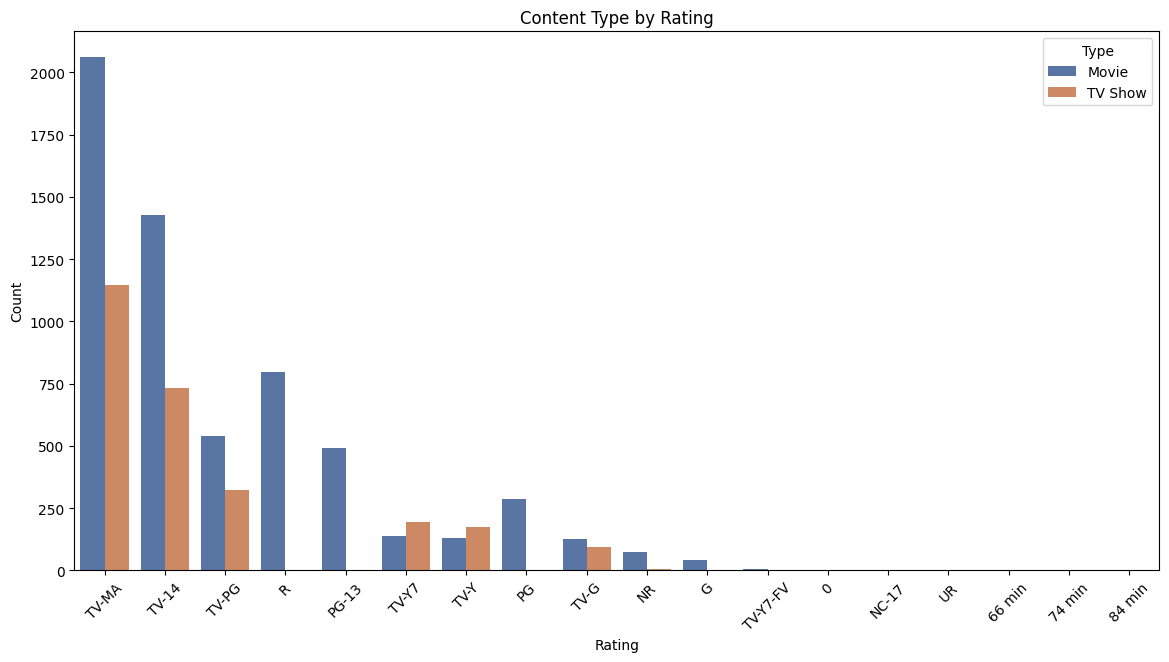


Association between 'type' and 'country' (top countries):
Chi-squared statistic: 798.23
P-value: 0.000
There is a significant association between content type and top 10 countries.


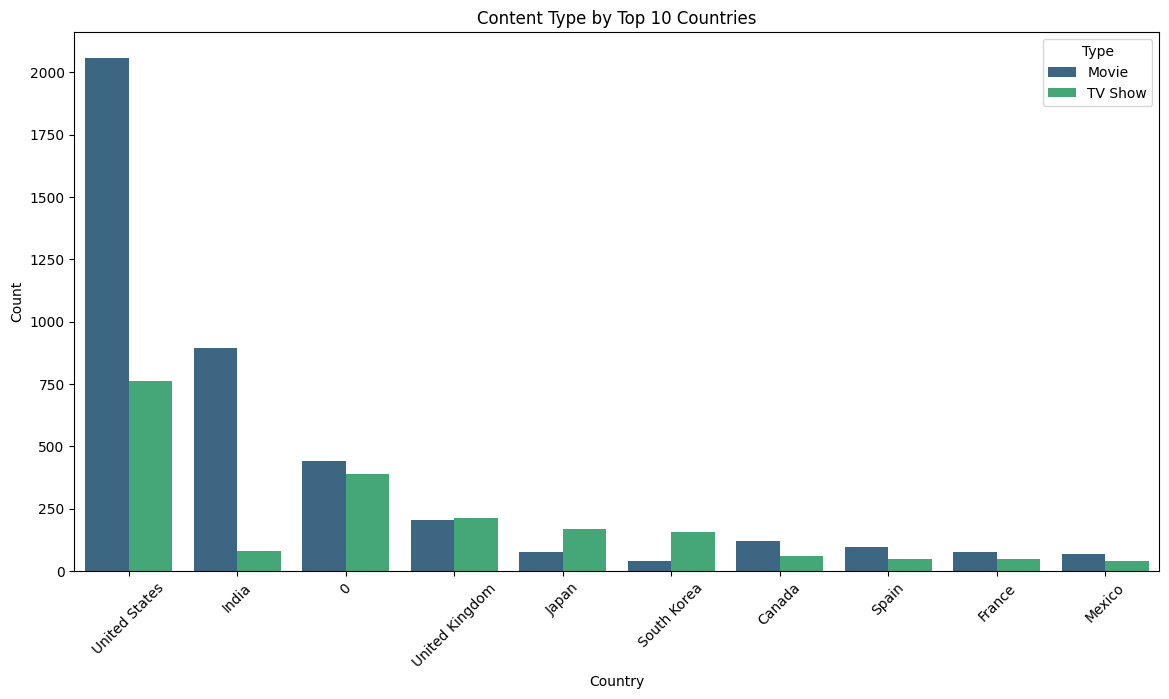

In [24]:
from scipy.stats import chi2_contingency

# Relationship between 'type' and 'rating'
print("\nAssociation between 'type' and 'rating':")
contingency_table_type_rating = pd.crosstab(df_cleaned['type'], df_cleaned['rating'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table_type_rating)
print(f"Chi-squared statistic: {chi2:.2f}")
print(f"P-value: {p_val:.3f}")
if p_val < 0.05:
    print("There is a significant association between content type and rating.")
else:
    print("There is no significant association between content type and rating.")

# Visualize the relationship
plt.figure(figsize=(14, 7))
sns.countplot(data=df_cleaned, x='rating', hue='type', order=df_cleaned['rating'].value_counts().index, palette='deep')
plt.title('Content Type by Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()

# Relationship between 'type' and 'country' (top 10 countries excluding '0')
print("\nAssociation between 'type' and 'country' (top countries):")
# Filter out the '0' country that resulted from fillna
df_filtered_country = df_cleaned[df_cleaned['country'] != '0']

top_countries = df_filtered_country['country'].value_counts().head(10).index
df_top_countries = df_filtered_country[df_filtered_country['country'].isin(top_countries)]

contingency_table_type_country = pd.crosstab(df_top_countries['type'], df_top_countries['country'])
chi2_country, p_val_country, dof_country, expected_country = chi2_contingency(contingency_table_type_country)
print(f"Chi-squared statistic: {chi2_country:.2f}")
print(f"P-value: {p_val_country:.3f}")
if p_val_country < 0.05:
    print("There is a significant association between content type and top 10 countries.")
else:
    print("There is no significant association between content type and top 10 countries.")

# Visualize the relationship
plt.figure(figsize=(14, 7))
sns.countplot(data=df_top_countries, x='country', hue='type', order=top_countries, palette='viridis')
plt.title('Content Type by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Type')
plt.show()
